# Linear Regression Model


# 1. Import Libaries


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from  sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# 2. Load Data Set

In [36]:


Data_set = pd.read_csv("../DataSets/fetch_california_housing.csv")


# 3. Explore the Dataset

In [37]:
print("------- Data set Info -----------")
print(Data_set.info())
print("------- Data set Sample -----------")
print(Data_set.head())
print("------- Data set Description -----------")
print(Data_set.describe())
print("------- Data set Columns -----------")
print(Data_set.columns)
print("------- Data set Null Values -----------")
print(Data_set.isnull().sum())
print("------- Data set Shape -----------")
print(Data_set.shape)
print("------- Data set Correlation -----------")
print(Data_set.corr())


------- Data set Info -----------
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
------- Data set Sample -----------
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5

# 4. Explore Data Ranges


In [38]:
print("------- Data set Ranges -----------")
for column in Data_set.columns:
    print(f"{column}: min={Data_set[column].min()}, max={Data_set[column].max()}")

------- Data set Ranges -----------
MedInc: min=0.4999, max=15.0001
HouseAge: min=1.0, max=52.0
AveRooms: min=0.8461538461538461, max=141.9090909090909
AveBedrms: min=0.3333333333333333, max=34.06666666666667
Population: min=3.0, max=35682.0
AveOccup: min=0.6923076923076923, max=1243.3333333333333
Latitude: min=32.54, max=41.95
Longitude: min=-124.35, max=-114.31
MedHouseVal: min=0.14999, max=5.00001


# 5. Features Correltions
#### This shows how strongly each feature is linearly related to the median house value.


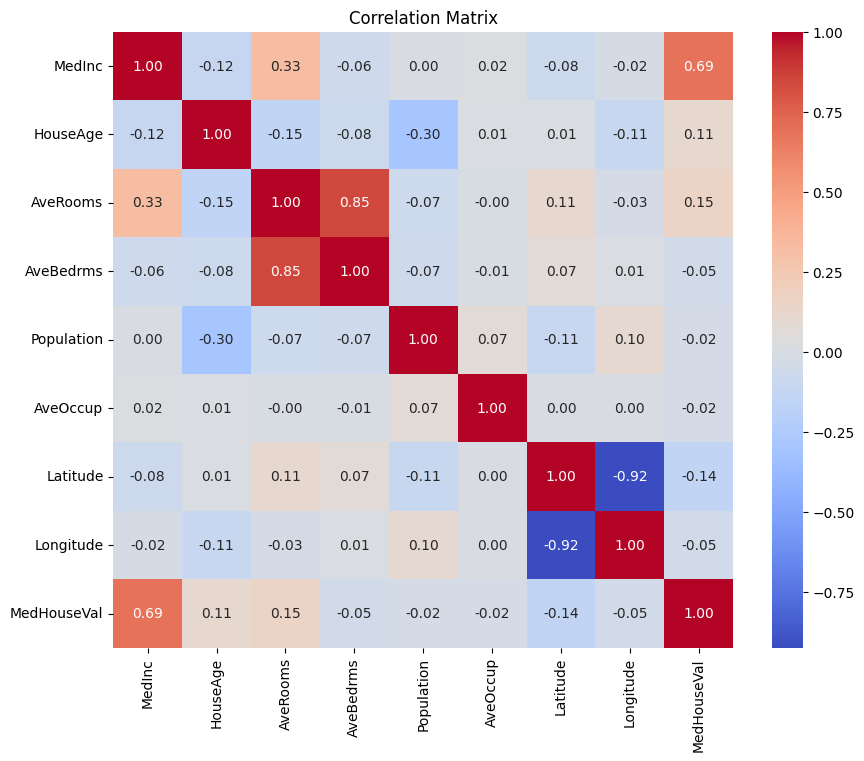

In [39]:


plt.figure(figsize=(10, 8))
sns.heatmap(
    Data_set.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

# 6. Separate Features and Target

In [40]:
X = Data_set.drop("MedHouseVal", axis=1)
y = Data_set["MedHouseVal"]


# 7. Train/Test Split
### 

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# 8. Feature Scaling

In [42]:


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 9. Train the Model

In [43]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.85, 0.12,-0.29,...,-0.04,-0.9 ,-0.87]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.072
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](8,)","[182.86,175.83,145. ,...,104.18, 36.96, 27.94]"


# 10. Make Prediction

In [44]:
y_pred =model.predict(X_test)

# 11 . Evaluate the Model

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²  :", r2_score(y_test, y_pred))
print("Model Score:", model.score(X_test, y_test))

MAE : 0.5332001304956566
MSE : 0.5558915986952442
RMSE: 0.7455813830127763
R²  : 0.575787706032451
Model Score: 0.575787706032451


# 12 . Inspect the Learned Coefficients

In [46]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients.sort_values(by="Coefficient", key=abs, ascending=False))

      Feature  Coefficient
6    Latitude    -0.896929
7   Longitude    -0.869842
0      MedInc     0.854383
3   AveBedrms     0.339259
2    AveRooms    -0.294410
1    HouseAge     0.122546
5    AveOccup    -0.040829
4  Population    -0.002308


# 13.Plot Actual vs. Predicted

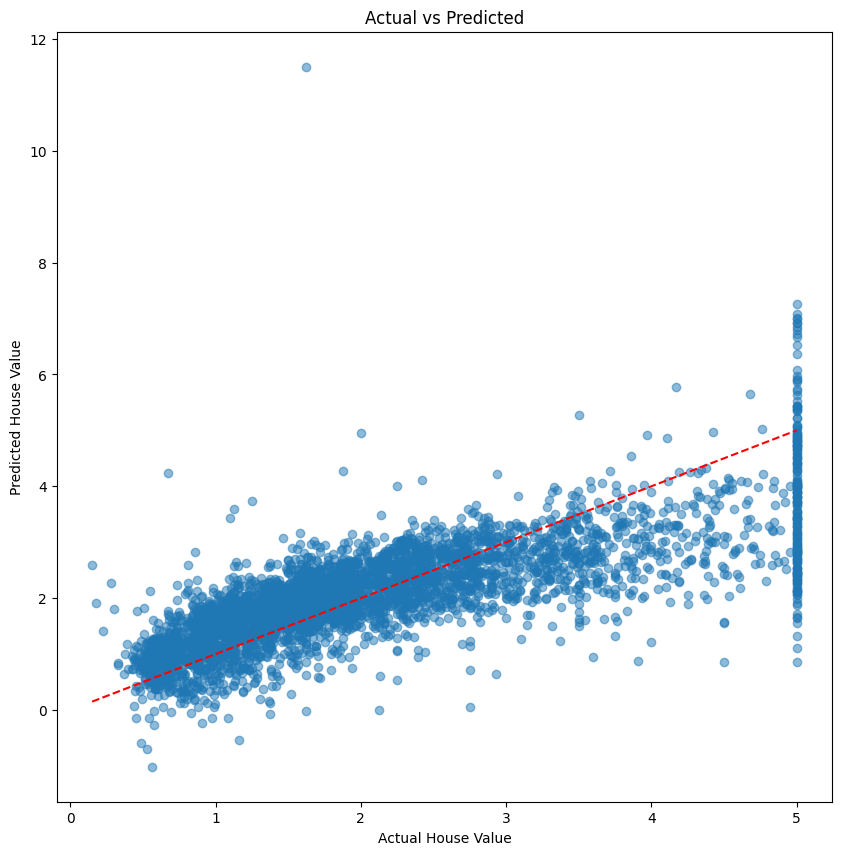

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--")
plt.show()